In [5]:
import sys
sys.path.append('/mnt/c/Users/Likun/ml-assignment-house-prices')

In [6]:
import os
import mlflow
import dagshub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

os.environ['DAGSHUB_USER_TOKEN'] = '6a076dbb1debcdd8e5e02d9e0bf45faf0b5adb13'
dagshub.init(repo_owner="lchit22", repo_name="ml-assignment-house-prices", mlflow=True)

train = pd.read_csv('Data/train.csv')
test = pd.read_csv('Data/test.csv')

print("Train shape:", train.shape)
print("Test shape:", test.shape)

Accessing as lchit22

Initialized MLflow to track repo "lchit22/ml-assignment-house-prices"

Repository lchit22/ml-assignment-house-prices initialized!

Train shape: (1460, 81)
Test shape: (1459, 80)


### House Prices - Advanced Regression Techniques
#### 1. Data Overview

In [7]:
print(f"Training set: {train.shape[0]} houses, {train.shape[1]} features")
print(f"Test set: {test.shape[0]} houses, {test.shape[1]} features")
print(f"\nCheapest house: ${train['SalePrice'].min():,}")
print(f"Most expensive house: ${train['SalePrice'].max():,}")
print(f"Average house price: ${train['SalePrice'].mean():,.0f}")
print(f"Median house price: ${train['SalePrice'].median():,.0f}")

Training set: 1460 houses, 81 features
Test set: 1459 houses, 80 features

Cheapest house: $34,900
Most expensive house: $755,000
Average house price: $180,921
Median house price: $163,000


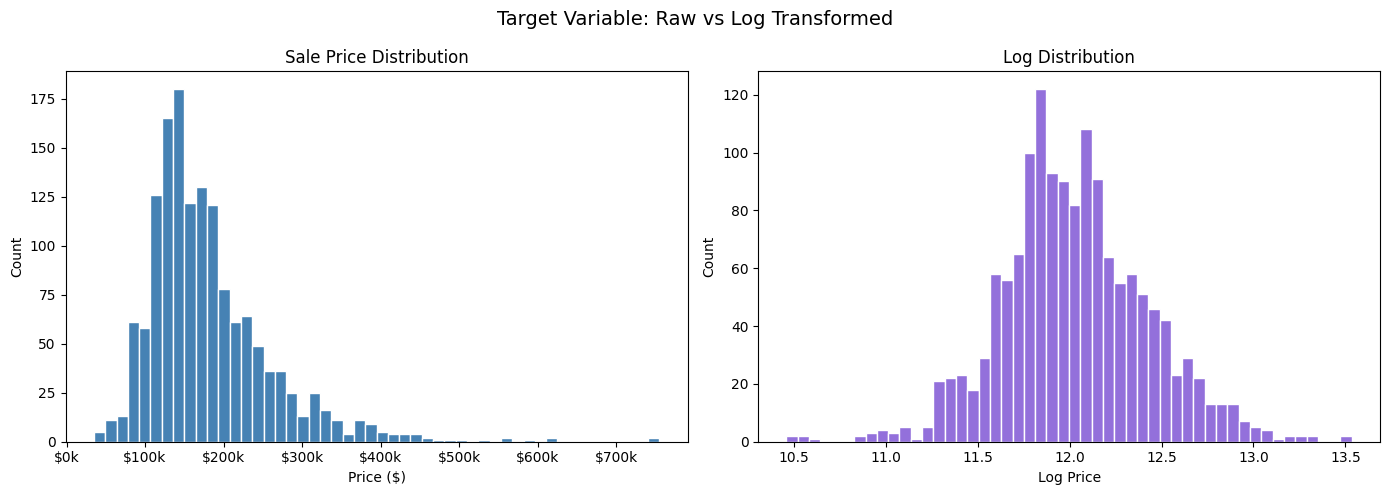

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(train['SalePrice'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Sale Price Distribution')
axes[0].set_xlabel('Price ($)')
axes[0].set_ylabel('Count')

axes[1].hist(np.log(train['SalePrice']), bins=50, color='mediumpurple', edgecolor='white')
axes[1].set_title('Log Distribution')
axes[1].set_xlabel('Log Price')
axes[1].set_ylabel('Count')

plt.suptitle('Target Variable: Raw vs Log Transformed', fontsize=14)
plt.tight_layout()
plt.savefig('plots/saleprice_distribution.png')
axes[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1000:.0f}k'))
plt.show()

In [9]:
# Missing values
missing = train.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing_pct = (missing / len(train) * 100).round(1)

missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print(missing_df)

              Missing Count  Missing %
PoolQC                 1453       99.5
MiscFeature            1406       96.3
Alley                  1369       93.8
Fence                  1179       80.8
MasVnrType              872       59.7
FireplaceQu             690       47.3
LotFrontage             259       17.7
GarageType               81        5.5
GarageYrBlt              81        5.5
GarageFinish             81        5.5
GarageQual               81        5.5
GarageCond               81        5.5
BsmtExposure             38        2.6
BsmtFinType2             38        2.6
BsmtQual                 37        2.5
BsmtCond                 37        2.5
BsmtFinType1             37        2.5
MasVnrArea                8        0.5
Electrical                1        0.1


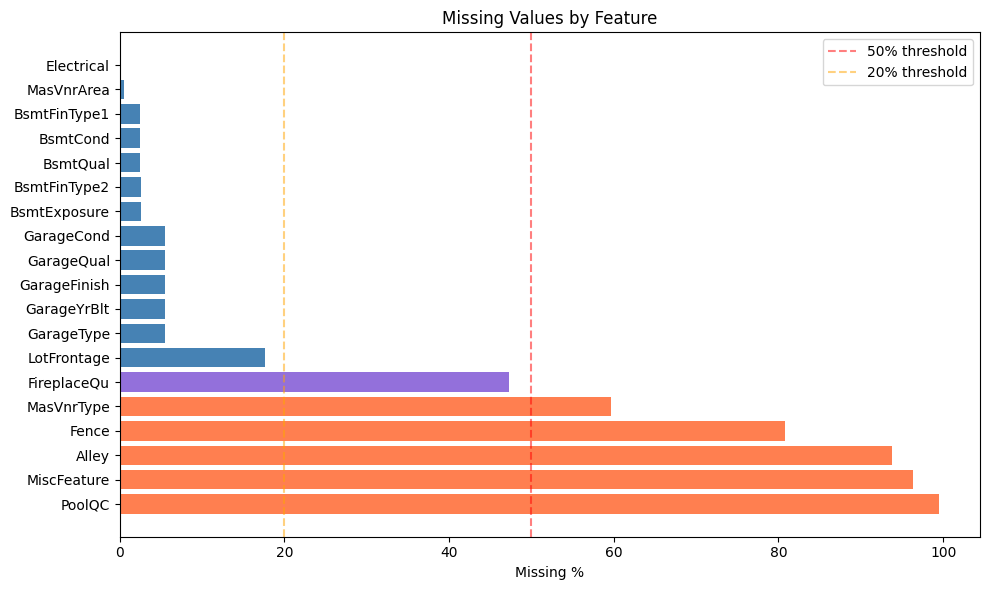

In [10]:
fig, ax = plt.subplots(figsize=(10, 6))

colors = ['coral' if pct > 50 else 'mediumpurple' if pct > 20 else 'steelblue' 
          for pct in missing_pct]

ax.barh(missing_df.index, missing_df['Missing %'], color=colors)
ax.set_xlabel('Missing %')
ax.set_title('Missing Values by Feature')
ax.axvline(x=50, color='red', linestyle='--', alpha=0.5, label='50% threshold')
ax.axvline(x=20, color='orange', linestyle='--', alpha=0.5, label='20% threshold')
ax.legend()

plt.tight_layout()
plt.savefig('plots/missing_values.png')
plt.show()

#### 2. Data Cleaning

In [11]:
#Approach 1: Drop high-missing columns, fill rest

def clean_approach1(df):
    df = df.copy()
    
    # drop columns with more than 20% missing
    high_missing = missing_pct[missing_pct > 20].index.tolist()
    df = df.drop(columns=high_missing)
    
    # fill remaining numeric nulls with median
    num_cols = df.select_dtypes(include='number').columns
    df[num_cols] = df[num_cols].fillna(df[num_cols].median())
    
    # fill remaining categorical nulls with mode
    cat_cols = df.select_dtypes(include='object').columns
    df[cat_cols] = df[cat_cols].fillna(df[cat_cols].mode().iloc[0])
    
    return df

train_c1 = clean_approach1(train)
print("Approach 1 shape:", train_c1.shape)
print("Remaining nulls:", train_c1.isnull().sum().sum())

Approach 1 shape: (1460, 75)
Remaining nulls: 0


In [12]:
#Approach 2: Intelligent filling based on domain knowledge

def clean_approach2(df):
    df = df.copy()
    
    # these NAs actually mean "None" / "No feature" based on data description
    none_cols = ['PoolQC', 'MiscFeature', 'Alley', 'Fence', 'FireplaceQu',
                 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond',
                 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 
                 'BsmtFinType2', 'MasVnrType']
    for col in none_cols:
        if col in df.columns:
            df[col] = df[col].fillna('None')
    
    # numeric cols where NA means 0
    zero_cols = ['GarageYrBlt', 'GarageArea', 'GarageCars', 
                 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF',
                 'TotalBsmtSF', 'MasVnrArea']
    for col in zero_cols:
        if col in df.columns:
            df[col] = df[col].fillna(0)
    
    # LotFrontage: fill with median of neighborhood
    df['LotFrontage'] = df.groupby('Neighborhood')['LotFrontage'].transform(
        lambda x: x.fillna(x.median())
    )
    
    # fill remaining
    num_cols = df.select_dtypes(include='number').columns
    df[num_cols] = df[num_cols].fillna(df[num_cols].median())
    cat_cols = df.select_dtypes(include='object').columns
    df[cat_cols] = df[cat_cols].fillna(df[cat_cols].mode().iloc[0])
    
    return df

train_c2 = clean_approach2(train)
print("Approach 2 shape:", train_c2.shape)
print("Remaining nulls:", train_c2.isnull().sum().sum())

Approach 2 shape: (1460, 81)
Remaining nulls: 0


In [13]:
print("Approach 1: dropped 6 high-missing columns, filled rest with median/mode")
print(f"  → {train_c1.shape[1]} features remaining")
print()
print("Approach 2: kept all columns, filled NAs based on domain knowledge")
print(f"  → {train_c2.shape[1]} features remaining")
print()
print("We will test both approaches during training to see which performs better")

Approach 1: dropped 6 high-missing columns, filled rest with median/mode
  → 75 features remaining

Approach 2: kept all columns, filled NAs based on domain knowledge
  → 81 features remaining

We will test both approaches during training to see which performs better


#### 3. Feature Engineering

In [14]:
def engineer_features(df):
    df = df.copy()
    
    # total area of house
    df['TotalSF'] = df['TotalBsmtSF'] + df['1stFlrSF'] + df['2ndFlrSF']
    
    # age of house when sold
    df['HouseAge'] = df['YrSold'] - df['YearBuilt']
    
    # years since remodel
    df['YearsSinceRemodel'] = df['YrSold'] - df['YearRemodAdd']
    
    # total bathrooms
    df['TotalBathrooms'] = (df['FullBath'] + df['BsmtFullBath'] + 
                            0.5 * df['HalfBath'] + 0.5 * df['BsmtHalfBath'])
    
    # has pool, has garage, has basement, has fireplace
    df['HasPool'] = (df['PoolArea'] > 0).astype(int)
    df['HasGarage'] = (df['GarageArea'] > 0).astype(int)
    df['HasBasement'] = (df['TotalBsmtSF'] > 0).astype(int)
    df['HasFireplace'] = (df['Fireplaces'] > 0).astype(int)
    
    # porch total area
    df['TotalPorchSF'] = (df['OpenPorchSF'] + df['EnclosedPorch'] + 
                          df['3SsnPorch'] + df['ScreenPorch'])
    
    return df

train_c1 = engineer_features(train_c1)
train_c2 = engineer_features(train_c2)

print("New features added:")
new_features = ['TotalSF', 'HouseAge', 'YearsSinceRemodel', 'TotalBathrooms',
                'HasPool', 'HasGarage', 'HasBasement', 'HasFireplace', 'TotalPorchSF']
print(train_c1[new_features].describe().round(2))

New features added:
        TotalSF  HouseAge  YearsSinceRemodel  TotalBathrooms  HasPool  \
count   1460.00   1460.00            1460.00         1460.00  1460.00   
mean    2567.05     36.55              22.95            2.21     0.00   
std      821.71     30.25              20.64            0.79     0.07   
min      334.00      0.00              -1.00            1.00     0.00   
25%     2009.50      8.00               4.00            2.00     0.00   
50%     2474.00     35.00              14.00            2.00     0.00   
75%     3004.00     54.00              41.00            2.50     0.00   
max    11752.00    136.00              60.00            6.00     1.00   

       HasGarage  HasBasement  HasFireplace  TotalPorchSF  
count    1460.00      1460.00       1460.00       1460.00  
mean        0.94         0.97          0.53         87.08  
std         0.23         0.16          0.50        105.19  
min         0.00         0.00          0.00          0.00  
25%         1.00      

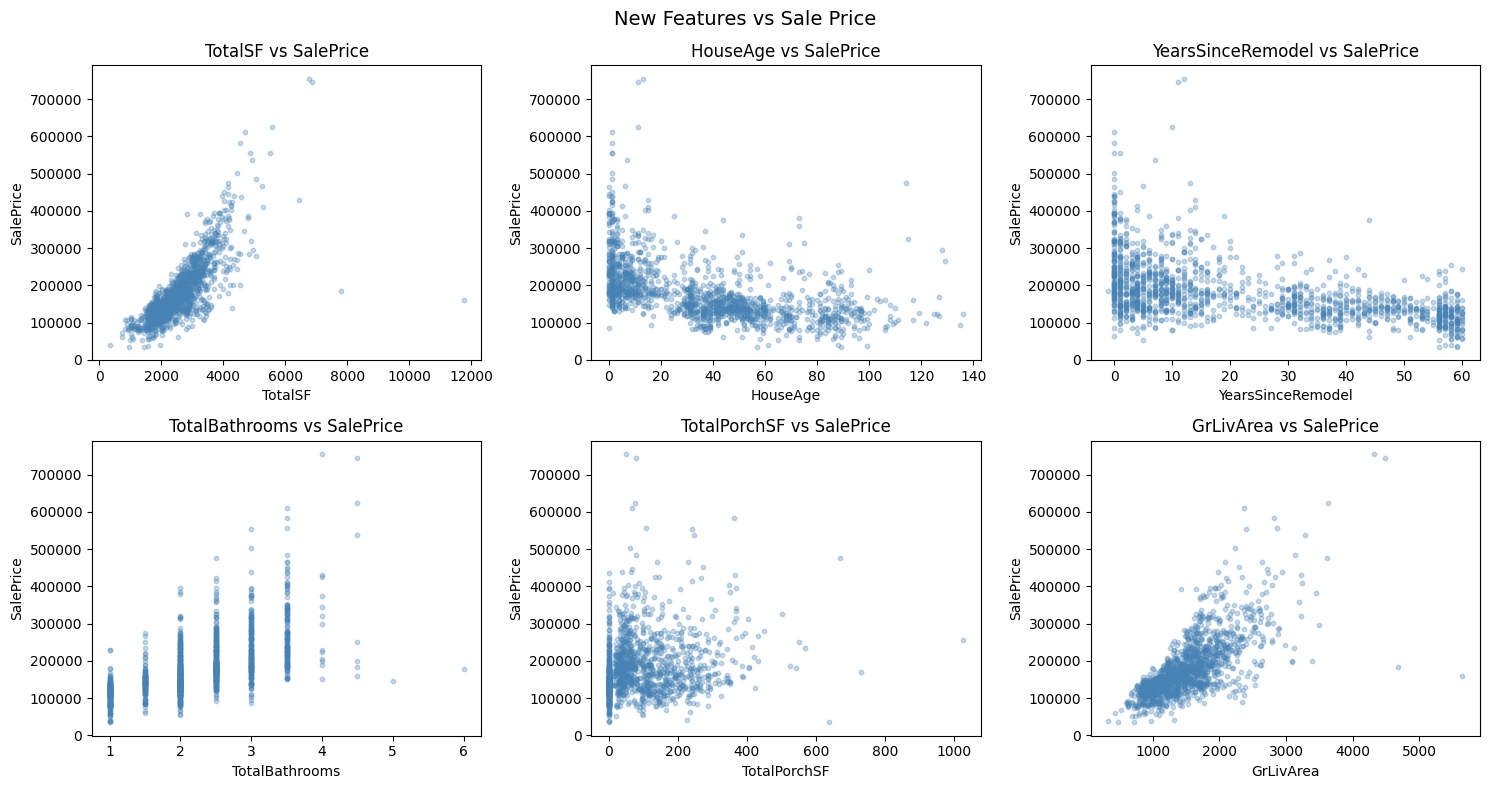

In [15]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

new_features = ['TotalSF', 'HouseAge', 'YearsSinceRemodel', 
                'TotalBathrooms', 'TotalPorchSF', 'TotalBathrooms']

for i, feat in enumerate(['TotalSF', 'HouseAge', 'YearsSinceRemodel', 
                           'TotalBathrooms', 'TotalPorchSF', 'GrLivArea']):
    axes[i].scatter(train_c2[feat], train_c2['SalePrice'], 
                    alpha=0.3, color='steelblue', s=10)
    axes[i].set_xlabel(feat)
    axes[i].set_ylabel('SalePrice')
    axes[i].set_title(f'{feat} vs SalePrice')

plt.suptitle('New Features vs Sale Price', fontsize=14)
plt.tight_layout()
plt.savefig('plots/feature_correlations.png')
plt.show()

In [16]:
def encode_features(df):
    df = df.copy()
    
    # ordinal encoding for quality columns (Poor to Excellent = 0 to 5)
    quality_map = {'None': 0, 'Po': 1, 'Fa': 2, 'TA': 3, 'Gd': 4, 'Ex': 5}
    quality_cols = ['ExterQual', 'ExterCond', 'BsmtQual', 'BsmtCond',
                    'HeatingQC', 'KitchenQual', 'FireplaceQu', 
                    'GarageQual', 'GarageCond', 'PoolQC']
    for col in quality_cols:
        if col in df.columns:
            df[col] = df[col].map(quality_map).fillna(0)
    
    # one hot encoding for remaining categoricals
    cat_cols = df.select_dtypes(include='object').columns.tolist()
    df = pd.get_dummies(df, columns=cat_cols, drop_first=True)
    
    return df

train_c1 = encode_features(train_c1)
train_c2 = encode_features(train_c2)

print("After encoding:")
print(f"Approach 1: {train_c1.shape[1]} features")
print(f"Approach 2: {train_c2.shape[1]} features")

After encoding:
Approach 1: 220 features
Approach 2: 240 features


In [17]:
print(f"Approach 1: went from 75 → 220 features after encoding")
print(f"Approach 2: went from 81 → 240 features after encoding")
print(f"\nOne-hot encoding expanded categorical columns into many binary columns")
print(f"Feature selection will reduce these to the most important ones")

Approach 1: went from 75 → 220 features after encoding
Approach 2: went from 81 → 240 features after encoding

One-hot encoding expanded categorical columns into many binary columns
Feature selection will reduce these to the most important ones


#### 4. Feature Selection

In [18]:
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.ensemble import RandomForestRegressor

# separate features and target
X1 = train_c1.drop(columns=['SalePrice'])
y1 = train_c1['SalePrice']

X2 = train_c2.drop(columns=['SalePrice'])
y2 = train_c2['SalePrice']

# --- Approach 1: SelectKBest (statistical test) ---
selector_kbest = SelectKBest(score_func=f_regression, k=50)
X1_kbest = selector_kbest.fit_transform(X1, y1)
X2_kbest = selector_kbest.fit_transform(X2, y2)

print(f"SelectKBest: kept 50 features from each approach")

# --- Approach 2: Feature Importance from Random Forest ---
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X1, y1)

importances = pd.Series(rf.feature_importances_, index=X1.columns)
top50 = importances.nlargest(50).index.tolist()
X1_rf = X1[top50]

rf.fit(X2, y2)
importances2 = pd.Series(rf.feature_importances_, index=X2.columns)
top50_2 = importances2.nlargest(50).index.tolist()
X2_rf = X2[top50_2]

print(f"Random Forest importance: kept top 50 features from each approach")

SelectKBest: kept 50 features from each approach
Random Forest importance: kept top 50 features from each approach


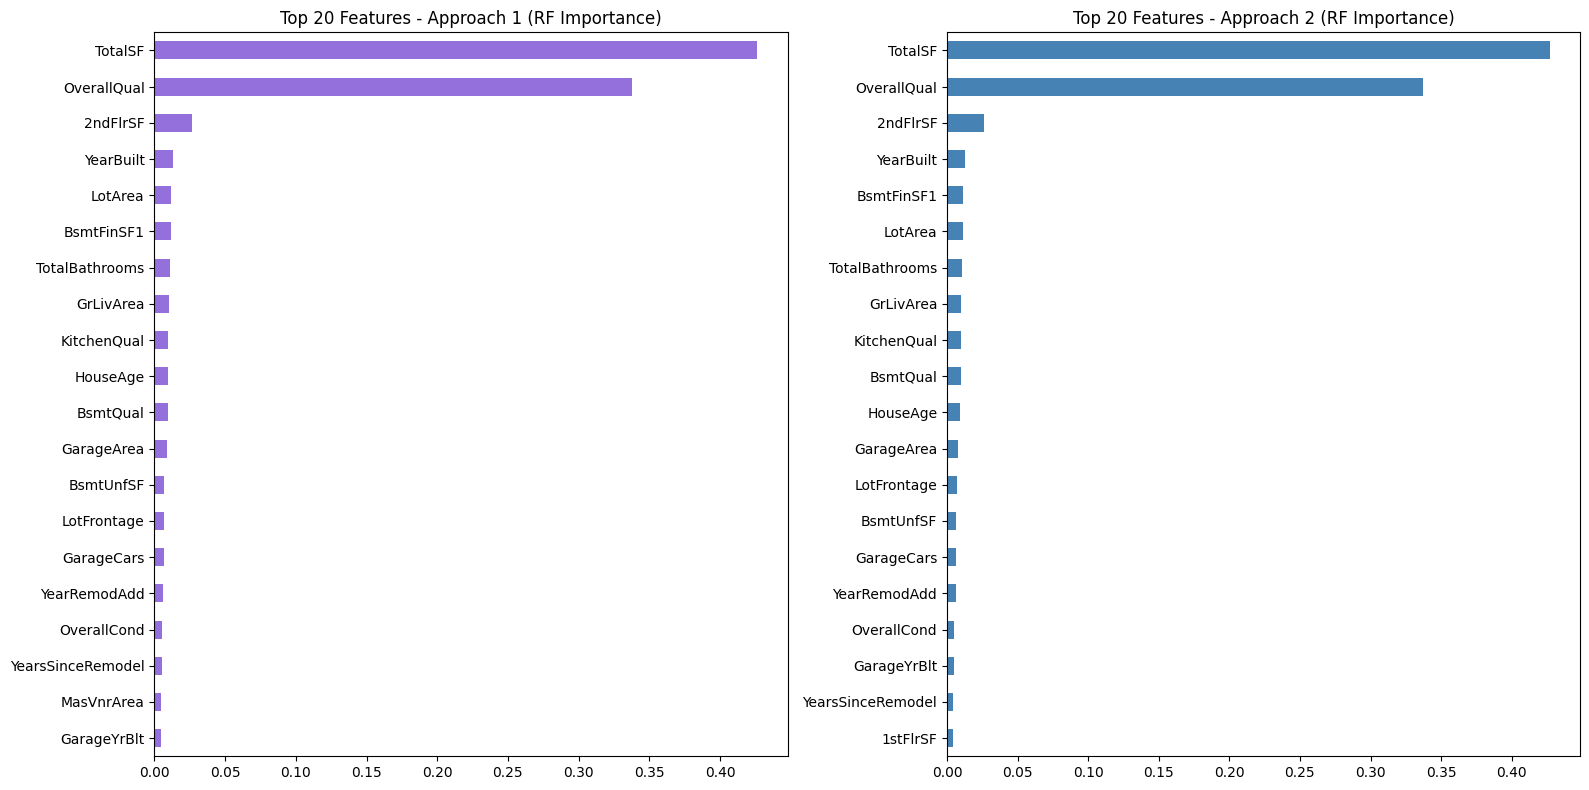

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# approach 1 top 20
importances.nlargest(20).plot(kind='barh', ax=axes[0], color='mediumpurple')
axes[0].set_title('Top 20 Features - Approach 1 (RF Importance)')
axes[0].invert_yaxis()

# approach 2 top 20
importances2.nlargest(20).plot(kind='barh', ax=axes[1], color='steelblue')
axes[1].set_title('Top 20 Features - Approach 2 (RF Importance)')
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig('plots/feature_importance.png')
plt.show()

In [20]:
from sklearn.model_selection import train_test_split

# we will use log of SalePrice as target (competition uses RMSE of log)
y1_log = np.log(y1)
y2_log = np.log(y2)

# final datasets: 4 combinations to test
# cleaning approach x feature selection approach
X1_kbest_train, X1_kbest_val, y1_train, y1_val = train_test_split(X1_kbest, y1_log, test_size=0.2, random_state=42)
X1_rf_train, X1_rf_val, _, _ = train_test_split(X1_rf, y1_log, test_size=0.2, random_state=42)
X2_kbest_train, X2_kbest_val, y2_train, y2_val = train_test_split(X2_kbest, y2_log, test_size=0.2, random_state=42)
X2_rf_train, X2_rf_val, _, _ = train_test_split(X2_rf, y2_log, test_size=0.2, random_state=42)

print("Training sets ready:")
print(f"X1_kbest: {X1_kbest_train.shape}, X1_rf: {X1_rf_train.shape}")
print(f"X2_kbest: {X2_kbest_train.shape}, X2_rf: {X2_rf_train.shape}")

Training sets ready:
X1_kbest: (1168, 50), X1_rf: (1168, 50)
X2_kbest: (1168, 50), X2_rf: (1168, 50)


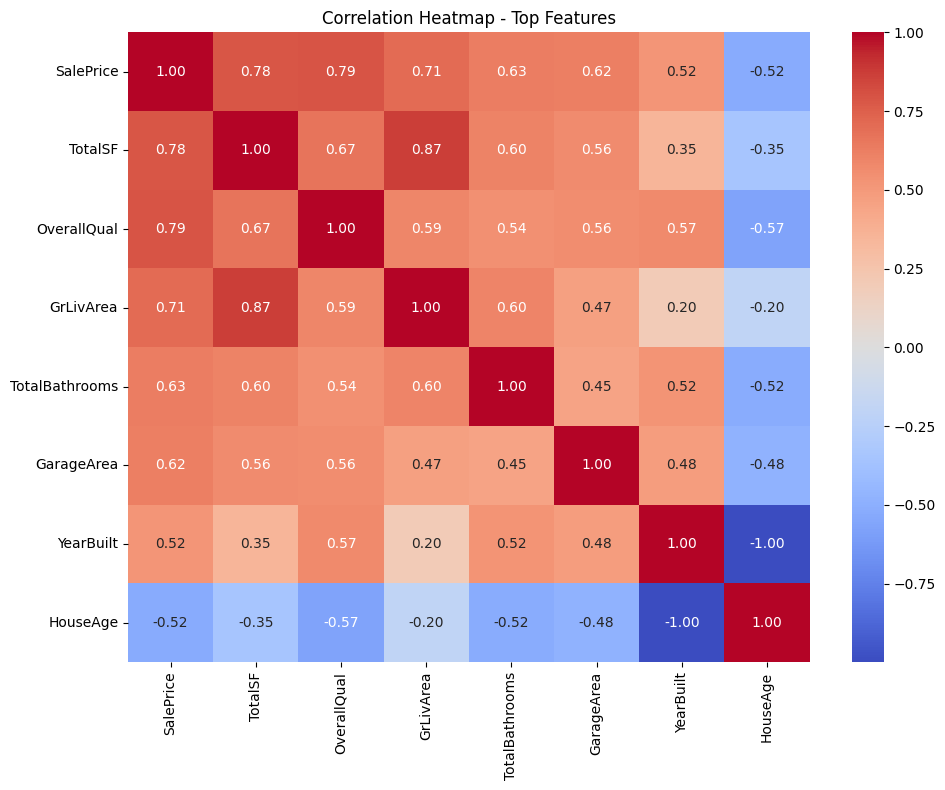

In [21]:
top_features = ['SalePrice', 'TotalSF', 'OverallQual', 'GrLivArea', 
                'TotalBathrooms', 'GarageArea', 'YearBuilt', 'HouseAge']

corr = train_c2[top_features].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Heatmap - Top Features')
plt.tight_layout()
plt.savefig('plots/correlation_heatmap.png')
plt.show()

In [26]:
def remove_correlated_features(X_train, X_other=None, threshold=0.85):
    if not isinstance(X_train, pd.DataFrame):
        X_train = pd.DataFrame(X_train)
    corr_matrix = X_train.corr().abs()
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    to_drop = [col for col in upper.columns if any(upper[col] > threshold)]
    X_train_filtered = X_train.drop(columns=to_drop)
    print(f"Removed {len(to_drop)} correlated features, {X_train_filtered.shape[1]} remaining")
    if X_other is not None:
        if not isinstance(X_other, pd.DataFrame):
            X_other = pd.DataFrame(X_other)
        X_other_filtered = X_other[X_train_filtered.columns]
        return X_train_filtered, X_other_filtered
    return X_train_filtered

X1_kbest_train_filtered, X1_kbest_val_filtered = remove_correlated_features(X1_kbest_train, X1_kbest_val)
X2_rf_train_filtered, X2_rf_val_filtered = remove_correlated_features(X2_rf_train, X2_rf_val)

Removed 7 correlated features, 43 remaining
Removed 6 correlated features, 44 remaining


#### 5. Training

##### 5.1 Linear regression

In [22]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import cross_val_score

def run_experiment(model, model_name, params, X_train, X_val, y_train, y_val, dataset_name, experiment_name):
    
    mlflow.set_experiment(experiment_name)
    
    with mlflow.start_run(run_name=f"{model_name}_{dataset_name}"):
        
        mlflow.log_param("model", model_name)
        mlflow.log_param("dataset", dataset_name)
        for key, val in params.items():
            mlflow.log_param(key, val)
        
        model.fit(X_train, y_train)
        
        train_preds = model.predict(X_train)
        val_preds = model.predict(X_val)
        
        train_rmse = np.sqrt(mean_squared_error(y_train, train_preds))
        val_rmse = np.sqrt(mean_squared_error(y_val, val_preds))
        train_mae = mean_absolute_error(y_train, train_preds)
        val_mae = mean_absolute_error(y_val, val_preds)
        train_r2 = r2_score(y_train, train_preds)
        val_r2 = r2_score(y_val, val_preds)
        
        cv_scores = cross_val_score(model, X_train, y_train, 
                                    cv=5, scoring='neg_root_mean_squared_error')
        cv_rmse_mean = -cv_scores.mean()
        cv_rmse_std = cv_scores.std()
        
        mlflow.log_metric("train_rmse", train_rmse)
        mlflow.log_metric("val_rmse", val_rmse)
        mlflow.log_metric("train_mae", train_mae)
        mlflow.log_metric("val_mae", val_mae)
        mlflow.log_metric("train_r2", train_r2)
        mlflow.log_metric("val_r2", val_r2)
        mlflow.log_metric("cv_rmse_mean", cv_rmse_mean)
        mlflow.log_metric("cv_rmse_std", cv_rmse_std)
        
        mlflow.sklearn.log_model(model, "model")
        
        print(f"{model_name} | {dataset_name} | train_rmse: {train_rmse:.4f} | val_rmse: {val_rmse:.4f} | cv_rmse: {cv_rmse_mean:.4f}")
        
        return val_rmse

In [ ]:
from sklearn.linear_model import LinearRegression

datasets = [
    (X1_kbest_train_filtered, X1_kbest_val_filtered, y1_train, y1_val, "approach1_kbest"),
    (X2_rf_train_filtered, X2_rf_val_filtered, y2_train, y2_val, "approach2_rf"),
]

for X_train, X_val, y_train, y_val, name in datasets:
    model = LinearRegression()
    run_experiment(
        model=model,
        model_name="LinearRegression",
        params={},
        X_train=X_train,
        X_val=X_val,
        y_train=y_train,
        y_val=y_val,
        dataset_name=name,
        experiment_name="linear_regression"
    )

2026/04/13 01:44:07 INFO mlflow.tracking.fluent: Experiment with name 'linear_regression' does not exist. Creating a new experiment.
2026/04/13 01:44:11 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/13 01:44:23 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


LinearRegression | approach1_kbest | train_rmse: 0.1427 | val_rmse: 0.1556 | cv_rmse: 0.1563
🏃 View run LinearRegression_approach1_kbest at: https://dagshub.com/lchit22/ml-assignment-house-prices.mlflow/#/experiments/0/runs/dfc988a334df4d16b97bbcced892d560
🧪 View experiment at: https://dagshub.com/lchit22/ml-assignment-house-prices.mlflow/#/experiments/0


2026/04/13 01:44:44 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/13 01:44:57 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


LinearRegression | approach2_rf | train_rmse: 0.1354 | val_rmse: 0.1461 | cv_rmse: 0.1476
🏃 View run LinearRegression_approach2_rf at: https://dagshub.com/lchit22/ml-assignment-house-prices.mlflow/#/experiments/0/runs/33bf7487852f4573a5b4dd40e57d8730
🧪 View experiment at: https://dagshub.com/lchit22/ml-assignment-house-prices.mlflow/#/experiments/0


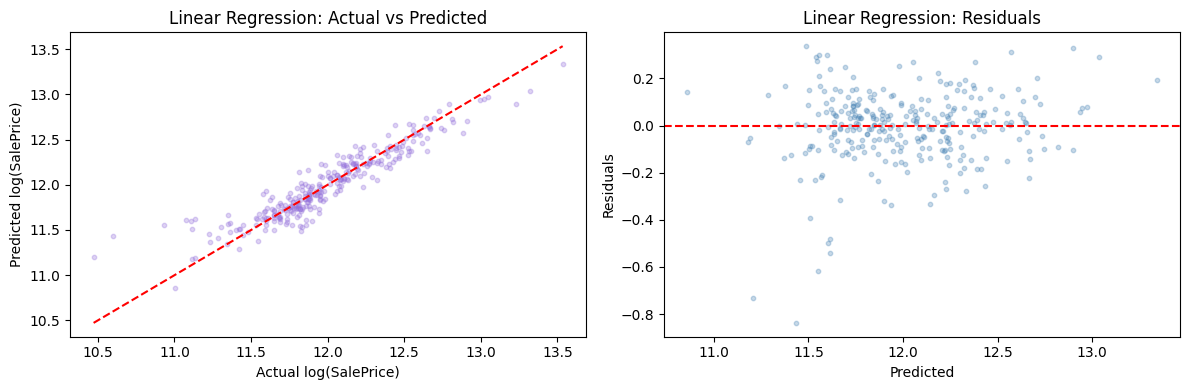

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# actual vs predicted
val_preds_lr = LinearRegression().fit(X1_kbest_train_filtered, y1_train).predict(X1_kbest_val_filtered)

axes[0].scatter(y1_val, val_preds_lr, alpha=0.3, color='mediumpurple', s=10)
axes[0].plot([y1_val.min(), y1_val.max()], [y1_val.min(), y1_val.max()], 'r--')
axes[0].set_xlabel('Actual log(SalePrice)')
axes[0].set_ylabel('Predicted log(SalePrice)')
axes[0].set_title('Linear Regression: Actual vs Predicted')

# residuals
residuals = y1_val - val_preds_lr
axes[1].scatter(val_preds_lr, residuals, alpha=0.3, color='steelblue', s=10)
axes[1].axhline(y=0, color='r', linestyle='--')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Residuals')
axes[1].set_title('Linear Regression: Residuals')

plt.tight_layout()
plt.savefig('plots/linear_regression_analysis.png')
plt.show()

##### 5.2 Ridge Regression

In [25]:
from sklearn.linear_model import Ridge

datasets = [
    (X1_kbest_train_filtered, X1_kbest_val_filtered, y1_train, y1_val, "approach1_kbest"),
    (X2_rf_train_filtered, X2_rf_val_filtered, y2_train, y2_val, "approach2_rf"),
]

alphas = [0.001, 0.01, 0.1, 1, 10, 100, 1000]

for alpha in alphas:
    for X_train, X_val, y_train, y_val, name in datasets:
        model = Ridge(alpha=alpha)
        run_experiment(
            model=model,
            model_name="Ridge",
            params={"alpha": alpha},
            X_train=X_train,
            X_val=X_val,
            y_train=y_train,
            y_val=y_val,
            dataset_name=name,
            experiment_name="ridge_regression"
        )

2026/04/13 12:09:30 INFO mlflow.tracking.fluent: Experiment with name 'ridge_regression' does not exist. Creating a new experiment.
2026/04/13 12:09:35 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/13 12:09:47 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Ridge | approach1_kbest | train_rmse: 0.1427 | val_rmse: 0.1556 | cv_rmse: 0.1563
🏃 View run Ridge_approach1_kbest at: https://dagshub.com/lchit22/ml-assignment-house-prices.mlflow/#/experiments/1/runs/2aaf74f7b91c414d86a544f79585631b
🧪 View experiment at: https://dagshub.com/lchit22/ml-assignment-house-prices.mlflow/#/experiments/1


2026/04/13 12:10:09 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/13 12:10:22 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Ridge | approach2_rf | train_rmse: 0.1354 | val_rmse: 0.1461 | cv_rmse: 0.1476
🏃 View run Ridge_approach2_rf at: https://dagshub.com/lchit22/ml-assignment-house-prices.mlflow/#/experiments/1/runs/b09aee77c9304e90a92a46c0b9f3535c
🧪 View experiment at: https://dagshub.com/lchit22/ml-assignment-house-prices.mlflow/#/experiments/1


2026/04/13 12:10:44 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/13 12:10:57 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


...

Ridge | approach2_rf | train_rmse: 0.1390 | val_rmse: 0.1478 | cv_rmse: 0.1498
🏃 View run Ridge_approach2_rf at: https://dagshub.com/lchit22/ml-assignment-house-prices.mlflow/#/experiments/1/runs/282a35d74da6458180ac4983724a1c91
🧪 View experiment at: https://dagshub.com/lchit22/ml-assignment-house-prices.mlflow/#/experiments/1


2026/04/13 12:16:34 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/13 12:16:47 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Ridge | approach1_kbest | train_rmse: 0.1641 | val_rmse: 0.1621 | cv_rmse: 0.1727
🏃 View run Ridge_approach1_kbest at: https://dagshub.com/lchit22/ml-assignment-house-prices.mlflow/#/experiments/1/runs/8c4be6a1f580465dbee2743c57bb5b69
🧪 View experiment at: https://dagshub.com/lchit22/ml-assignment-house-prices.mlflow/#/experiments/1


2026/04/13 12:17:09 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/13 12:17:22 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Ridge | approach2_rf | train_rmse: 0.1510 | val_rmse: 0.1562 | cv_rmse: 0.1615
🏃 View run Ridge_approach2_rf at: https://dagshub.com/lchit22/ml-assignment-house-prices.mlflow/#/experiments/1/runs/63c391534ccf43c2bcbd550b7cd24323
🧪 View experiment at: https://dagshub.com/lchit22/ml-assignment-house-prices.mlflow/#/experiments/1


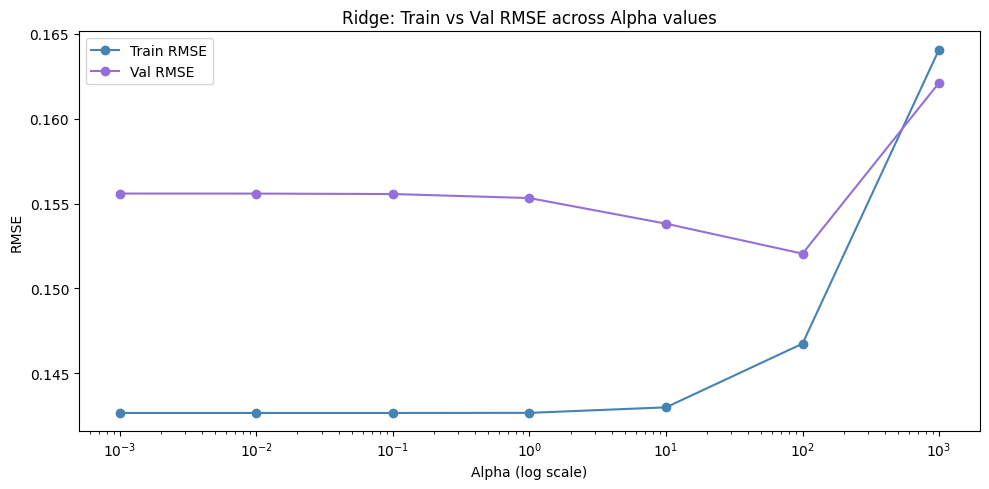

In [26]:
fig, ax = plt.subplots(figsize=(10, 5))

ridge_results = {'alpha': [], 'train_rmse': [], 'val_rmse': []}

for alpha in alphas:
    model = Ridge(alpha=alpha)
    model.fit(X1_kbest_train_filtered, y1_train)
    train_rmse = np.sqrt(mean_squared_error(y1_train, model.predict(X1_kbest_train_filtered)))
    val_rmse = np.sqrt(mean_squared_error(y1_val, model.predict(X1_kbest_val_filtered)))
    ridge_results['alpha'].append(alpha)
    ridge_results['train_rmse'].append(train_rmse)
    ridge_results['val_rmse'].append(val_rmse)

ax.plot(ridge_results['alpha'], ridge_results['train_rmse'], 'o-', color='steelblue', label='Train RMSE')
ax.plot(ridge_results['alpha'], ridge_results['val_rmse'], 'o-', color='mediumpurple', label='Val RMSE')
ax.set_xscale('log')
ax.set_xlabel('Alpha (log scale)')
ax.set_ylabel('RMSE')
ax.set_title('Ridge: Train vs Val RMSE across Alpha values')
ax.legend()
plt.tight_layout()
plt.savefig('plots/ridge_alpha_analysis.png')
plt.show()

##### 5.3 Lasso Regression

In [27]:
from sklearn.linear_model import Lasso

datasets = [
    (X1_kbest_train_filtered, X1_kbest_val_filtered, y1_train, y1_val, "approach1_kbest"),
    (X2_rf_train_filtered, X2_rf_val_filtered, y2_train, y2_val, "approach2_rf"),
]

alphas = [0.0001, 0.001, 0.01, 0.1, 1, 10, 100]

for alpha in alphas:
    for X_train, X_val, y_train, y_val, name in datasets:
        model = Lasso(alpha=alpha, max_iter=10000)
        run_experiment(
            model=model,
            model_name="Lasso",
            params={"alpha": alpha},
            X_train=X_train,
            X_val=X_val,
            y_train=y_train,
            y_val=y_val,
            dataset_name=name,
            experiment_name="lasso_regression"
        )

2026/04/13 12:47:52 INFO mlflow.tracking.fluent: Experiment with name 'lasso_regression' does not exist. Creating a new experiment.
2026/04/13 12:47:59 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/13 12:48:09 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Lasso | approach1_kbest | train_rmse: 0.1427 | val_rmse: 0.1550 | cv_rmse: 0.1562
🏃 View run Lasso_approach1_kbest at: https://dagshub.com/lchit22/ml-assignment-house-prices.mlflow/#/experiments/2/runs/8186d70359a442ed9d4054d8f6adf355
🧪 View experiment at: https://dagshub.com/lchit22/ml-assignment-house-prices.mlflow/#/experiments/2


/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 9.472e+00, tolerance: 1.781e-02
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 7.814e+00, tolerance: 1.428e-02
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 7.114e+00, tolerance: 1.436e

Lasso | approach2_rf | train_rmse: 0.1354 | val_rmse: 0.1459 | cv_rmse: 0.1475
🏃 View run Lasso_approach2_rf at: https://dagshub.com/lchit22/ml-assignment-house-prices.mlflow/#/experiments/2/runs/32829a720ccb4bf08615a10d52739841
🧪 View experiment at: https://dagshub.com/lchit22/ml-assignment-house-prices.mlflow/#/experiments/2


2026/04/13 12:49:06 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/13 12:49:19 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


...

Lasso | approach2_rf | train_rmse: 0.2337 | val_rmse: 0.2318 | cv_rmse: 0.2348
🏃 View run Lasso_approach2_rf at: https://dagshub.com/lchit22/ml-assignment-house-prices.mlflow/#/experiments/2/runs/8137169a74484f62a1a2fe4b2a87d86b
🧪 View experiment at: https://dagshub.com/lchit22/ml-assignment-house-prices.mlflow/#/experiments/2


2026/04/13 12:54:57 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/13 12:55:10 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Lasso | approach1_kbest | train_rmse: 0.3427 | val_rmse: 0.3808 | cv_rmse: 0.3455
🏃 View run Lasso_approach1_kbest at: https://dagshub.com/lchit22/ml-assignment-house-prices.mlflow/#/experiments/2/runs/f8970511485b46369569d6cb3c4a328f
🧪 View experiment at: https://dagshub.com/lchit22/ml-assignment-house-prices.mlflow/#/experiments/2


2026/04/13 12:55:31 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/13 12:55:44 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Lasso | approach2_rf | train_rmse: 0.2822 | val_rmse: 0.3046 | cv_rmse: 0.2818
🏃 View run Lasso_approach2_rf at: https://dagshub.com/lchit22/ml-assignment-house-prices.mlflow/#/experiments/2/runs/5e8841058fcc456c9c22c55e5688b8b3
🧪 View experiment at: https://dagshub.com/lchit22/ml-assignment-house-prices.mlflow/#/experiments/2


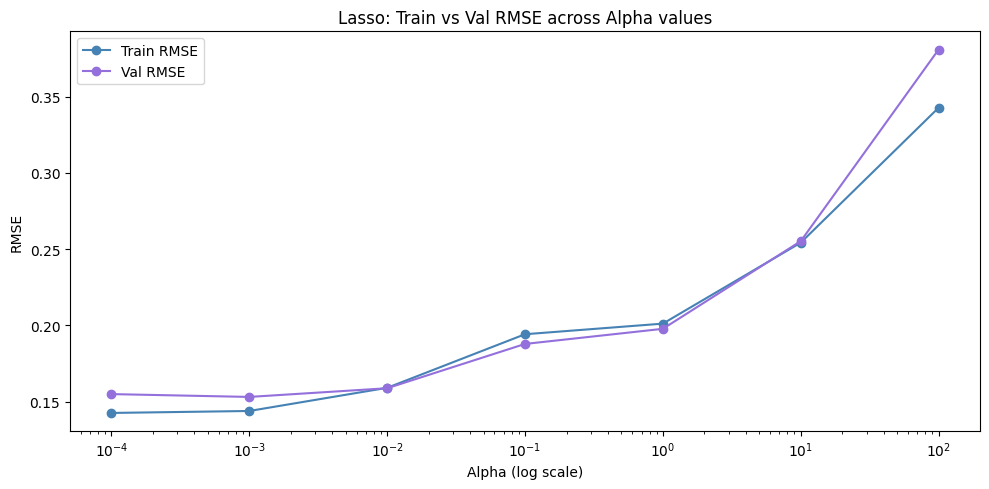

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))

lasso_alphas = [0.0001, 0.001, 0.01, 0.1, 1, 10, 100]
lasso_train_rmse = []
lasso_val_rmse = []

for alpha in lasso_alphas:
    model = Lasso(alpha=alpha, max_iter=10000)
    model.fit(X1_kbest_train_filtered, y1_train)
    lasso_train_rmse.append(np.sqrt(mean_squared_error(y1_train, model.predict(X1_kbest_train_filtered))))
    lasso_val_rmse.append(np.sqrt(mean_squared_error(y1_val, model.predict(X1_kbest_val_filtered))))

ax.plot(lasso_alphas, lasso_train_rmse, 'o-', color='steelblue', label='Train RMSE')
ax.plot(lasso_alphas, lasso_val_rmse, 'o-', color='mediumpurple', label='Val RMSE')
ax.set_xscale('log')
ax.set_xlabel('Alpha (log scale)')
ax.set_ylabel('RMSE')
ax.set_title('Lasso: Train vs Val RMSE across Alpha values')
ax.legend()
plt.tight_layout()
plt.savefig('plots/lasso_alpha_analysis.png')
plt.show()

##### 5.4 Decision Tree

In [29]:
from sklearn.tree import DecisionTreeRegressor


datasets = [
    (X1_kbest_train_filtered, X1_kbest_val_filtered, y1_train, y1_val, "approach1_kbest"),
    (X2_rf_train_filtered, X2_rf_val_filtered, y2_train, y2_val, "approach2_rf"),
]

depths = [2, 3, 4, 5, 10, 20, None]
min_samples_splits = [2, 4, 5, 10]

for depth in depths:
    for min_split in min_samples_splits:
        for X_train, X_val, y_train, y_val, name in datasets:
            model = DecisionTreeRegressor(max_depth=depth, min_samples_split=min_split, random_state=42)
            run_experiment(
                model=model,
                model_name="DecisionTree",
                params={"max_depth": str(depth), "min_samples_split": min_split},
                X_train=X_train,
                X_val=X_val,
                y_train=y_train,
                y_val=y_val,
                dataset_name=name,
                experiment_name="decision_tree"
            )

2026/04/13 14:48:48 INFO mlflow.tracking.fluent: Experiment with name 'decision_tree' does not exist. Creating a new experiment.
2026/04/13 14:48:53 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/13 14:49:06 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


DecisionTree | approach1_kbest | train_rmse: 0.2439 | val_rmse: 0.2646 | cv_rmse: 0.2548
🏃 View run DecisionTree_approach1_kbest at: https://dagshub.com/lchit22/ml-assignment-house-prices.mlflow/#/experiments/3/runs/e4ea3046800a40d5ade492cc34ec2e34
🧪 View experiment at: https://dagshub.com/lchit22/ml-assignment-house-prices.mlflow/#/experiments/3


2026/04/13 14:49:29 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/13 14:49:42 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


DecisionTree | approach2_rf | train_rmse: 0.2255 | val_rmse: 0.2363 | cv_rmse: 0.2279
🏃 View run DecisionTree_approach2_rf at: https://dagshub.com/lchit22/ml-assignment-house-prices.mlflow/#/experiments/3/runs/8e58bf82af9d42198d4f7e8162527330
🧪 View experiment at: https://dagshub.com/lchit22/ml-assignment-house-prices.mlflow/#/experiments/3


2026/04/13 14:50:05 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/13 14:50:18 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


...

DecisionTree | approach2_rf | train_rmse: 0.0383 | val_rmse: 0.2135 | cv_rmse: 0.2132
🏃 View run DecisionTree_approach2_rf at: https://dagshub.com/lchit22/ml-assignment-house-prices.mlflow/#/experiments/3/runs/3cda286a8fae44ca9c9f69c76648cdda
🧪 View experiment at: https://dagshub.com/lchit22/ml-assignment-house-prices.mlflow/#/experiments/3


2026/04/13 15:21:44 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/13 15:21:57 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


DecisionTree | approach1_kbest | train_rmse: 0.0681 | val_rmse: 0.1902 | cv_rmse: 0.2096
🏃 View run DecisionTree_approach1_kbest at: https://dagshub.com/lchit22/ml-assignment-house-prices.mlflow/#/experiments/3/runs/e6f33cee7f3d453f91ad8e91d39a3f43
🧪 View experiment at: https://dagshub.com/lchit22/ml-assignment-house-prices.mlflow/#/experiments/3


2026/04/13 15:22:20 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/13 15:22:33 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


DecisionTree | approach2_rf | train_rmse: 0.0674 | val_rmse: 0.1847 | cv_rmse: 0.1980
🏃 View run DecisionTree_approach2_rf at: https://dagshub.com/lchit22/ml-assignment-house-prices.mlflow/#/experiments/3/runs/a23c5e55f58f4b689fd28c1126467c29
🧪 View experiment at: https://dagshub.com/lchit22/ml-assignment-house-prices.mlflow/#/experiments/3


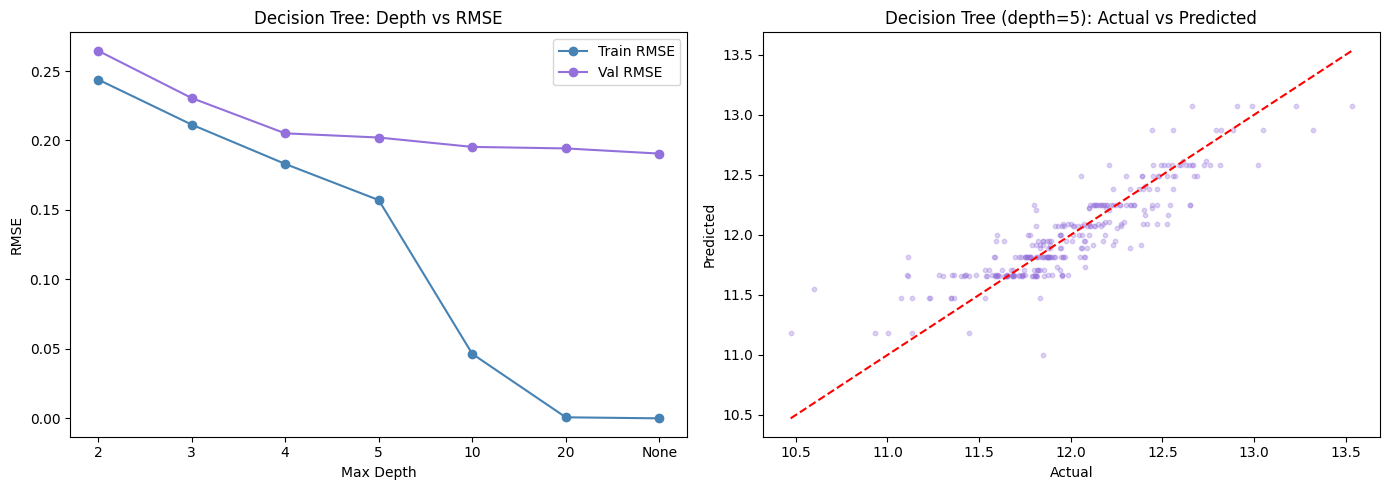

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

depth_labels = ['2', '3', '4', '5', '10', '20', 'None']
train_rmses = []
val_rmses = []

for depth in [2, 3, 4, 5, 10, 20, None]:
    model = DecisionTreeRegressor(max_depth=depth, min_samples_split=2, random_state=42)
    model.fit(X1_kbest_train_filtered, y1_train)
    train_rmses.append(np.sqrt(mean_squared_error(y1_train, model.predict(X1_kbest_train_filtered))))
    val_rmses.append(np.sqrt(mean_squared_error(y1_val, model.predict(X1_kbest_val_filtered))))

axes[0].plot(depth_labels, train_rmses, 'o-', color='steelblue', label='Train RMSE')
axes[0].plot(depth_labels, val_rmses, 'o-', color='mediumpurple', label='Val RMSE')
axes[0].set_xlabel('Max Depth')
axes[0].set_ylabel('RMSE')
axes[0].set_title('Decision Tree: Depth vs RMSE')
axes[0].legend()

axes[1].scatter(y1_val, DecisionTreeRegressor(max_depth=5, random_state=42)
               .fit(X1_kbest_train_filtered, y1_train)
               .predict(X1_kbest_val_filtered), 
               alpha=0.3, color='mediumpurple', s=10)
axes[1].plot([y1_val.min(), y1_val.max()], [y1_val.min(), y1_val.max()], 'r--')
axes[1].set_title('Decision Tree (depth=5): Actual vs Predicted')
axes[1].set_xlabel('Actual')
axes[1].set_ylabel('Predicted')

plt.tight_layout()
plt.savefig('plots/decision_tree_analysis.png')
plt.show()

##### 5.5 Random Forest

In [31]:
from sklearn.ensemble import RandomForestRegressor

datasets = [
    (X1_kbest_train_filtered, X1_kbest_val_filtered, y1_train, y1_val, "approach1_kbest"),
    (X2_rf_train_filtered, X2_rf_val_filtered, y2_train, y2_val, "approach2_rf"),
]

n_estimators_list = [50, 100, 200, 300]
max_depths = [3, 5, 10, 20, 25, None]

for n_est in n_estimators_list:
    for depth in max_depths:
        for X_train, X_val, y_train, y_val, name in datasets:
            model = RandomForestRegressor(n_estimators=n_est, max_depth=depth, random_state=42, n_jobs=-1)
            run_experiment(
                model=model,
                model_name="RandomForest",
                params={"n_estimators": n_est, "max_depth": str(depth)},
                X_train=X_train,
                X_val=X_val,
                y_train=y_train,
                y_val=y_val,
                dataset_name=name,
                experiment_name="random_forest"
            )

2026/04/13 16:30:32 INFO mlflow.tracking.fluent: Experiment with name 'random_forest' does not exist. Creating a new experiment.
2026/04/13 16:30:38 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/13 16:30:50 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


RandomForest | approach1_kbest | train_rmse: 0.1823 | val_rmse: 0.2025 | cv_rmse: 0.1936
🏃 View run RandomForest_approach1_kbest at: https://dagshub.com/lchit22/ml-assignment-house-prices.mlflow/#/experiments/4/runs/ff736db4b01f40b9b5c3e49bb8924c0c
🧪 View experiment at: https://dagshub.com/lchit22/ml-assignment-house-prices.mlflow/#/experiments/4


2026/04/13 16:31:13 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/13 16:31:26 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


RandomForest | approach2_rf | train_rmse: 0.1725 | val_rmse: 0.1898 | cv_rmse: 0.1790
🏃 View run RandomForest_approach2_rf at: https://dagshub.com/lchit22/ml-assignment-house-prices.mlflow/#/experiments/4/runs/e7b8c84e50704a93a0d24edf947040ec
🧪 View experiment at: https://dagshub.com/lchit22/ml-assignment-house-prices.mlflow/#/experiments/4


2026/04/13 16:32:07 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/13 16:32:15 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


...

RandomForest | approach2_rf | train_rmse: 0.0522 | val_rmse: 0.1493 | cv_rmse: 0.1421
🏃 View run RandomForest_approach2_rf at: https://dagshub.com/lchit22/ml-assignment-house-prices.mlflow/#/experiments/4/runs/1823997f876b42c7bfd02fffee279d85
🧪 View experiment at: https://dagshub.com/lchit22/ml-assignment-house-prices.mlflow/#/experiments/4


2026/04/13 17:04:45 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/13 17:04:53 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


RandomForest | approach1_kbest | train_rmse: 0.0534 | val_rmse: 0.1503 | cv_rmse: 0.1466
🏃 View run RandomForest_approach1_kbest at: https://dagshub.com/lchit22/ml-assignment-house-prices.mlflow/#/experiments/4/runs/b60110a186c84e56a84518713abda08b
🧪 View experiment at: https://dagshub.com/lchit22/ml-assignment-house-prices.mlflow/#/experiments/4


2026/04/13 17:05:59 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/13 17:06:10 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


RandomForest | approach2_rf | train_rmse: 0.0522 | val_rmse: 0.1493 | cv_rmse: 0.1421
🏃 View run RandomForest_approach2_rf at: https://dagshub.com/lchit22/ml-assignment-house-prices.mlflow/#/experiments/4/runs/2340ad8d01364e76b44203c3c7cdf1e0
🧪 View experiment at: https://dagshub.com/lchit22/ml-assignment-house-prices.mlflow/#/experiments/4


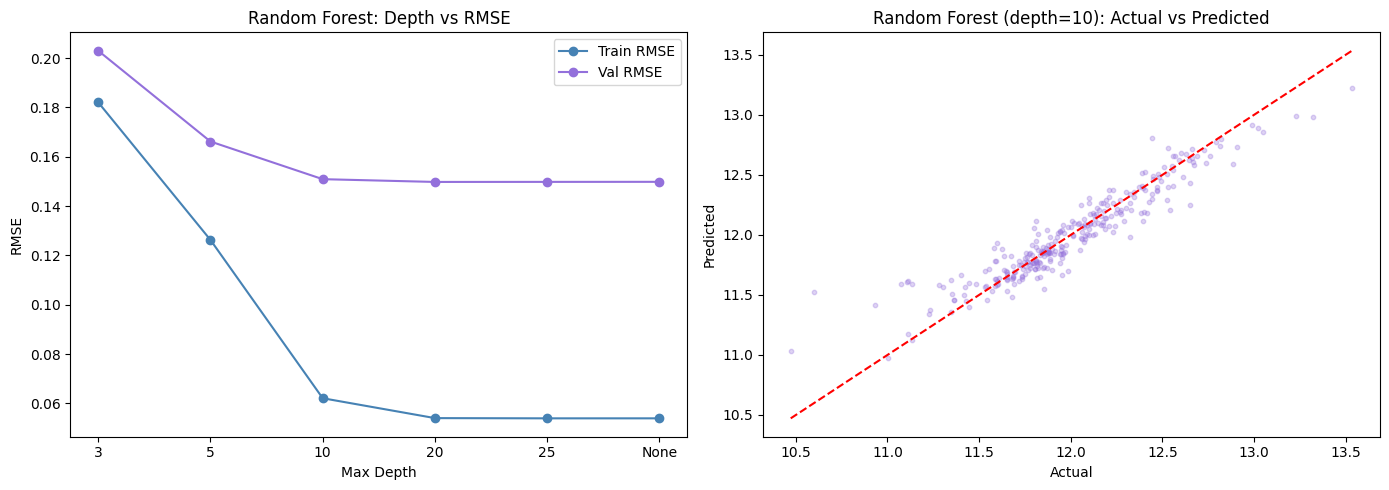

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

depth_labels = ['3', '5', '10', '20', '25', 'None']
rf_train_rmses = []
rf_val_rmses = []

for depth in [3, 5, 10, 20, 25, None]:
    model = RandomForestRegressor(n_estimators=100, max_depth=depth, random_state=42, n_jobs=-1)
    model.fit(X1_kbest_train_filtered, y1_train)
    rf_train_rmses.append(np.sqrt(mean_squared_error(y1_train, model.predict(X1_kbest_train_filtered))))
    rf_val_rmses.append(np.sqrt(mean_squared_error(y1_val, model.predict(X1_kbest_val_filtered))))

axes[0].plot(depth_labels, rf_train_rmses, 'o-', color='steelblue', label='Train RMSE')
axes[0].plot(depth_labels, rf_val_rmses, 'o-', color='mediumpurple', label='Val RMSE')
axes[0].set_xlabel('Max Depth')
axes[0].set_ylabel('RMSE')
axes[0].set_title('Random Forest: Depth vs RMSE')
axes[0].legend()

axes[1].scatter(y1_val, RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
               .fit(X1_kbest_train_filtered, y1_train)
               .predict(X1_kbest_val_filtered),
               alpha=0.3, color='mediumpurple', s=10)
axes[1].plot([y1_val.min(), y1_val.max()], [y1_val.min(), y1_val.max()], 'r--')
axes[1].set_title('Random Forest (depth=10): Actual vs Predicted')
axes[1].set_xlabel('Actual')
axes[1].set_ylabel('Predicted')

plt.tight_layout()
plt.savefig('plots/random_forest_analysis.png')
plt.show()

#### 6. Best Model Selection

In [36]:
import mlflow

best_run = mlflow.search_runs(
    experiment_names=["linear_regression", "ridge_regression", 
                      "lasso_regression", "decision_tree", "random_forest"],
    order_by=["metrics.val_rmse ASC"]
).iloc[0]

print("Best model:")
print(f"  Run ID: {best_run['run_id']}")
print(f"  Experiment: {best_run['experiment_id']}")
print(f"  val_rmse: {best_run['metrics.val_rmse']:.4f}")
print(f"  train_rmse: {best_run['metrics.train_rmse']:.4f}")
print(f"  Model: {best_run['params.model']}")
print(f"  Dataset: {best_run['params.dataset']}")

all_runs = mlflow.search_runs(
    experiment_names=["linear_regression", "ridge_regression", 
                      "lasso_regression", "decision_tree", "random_forest"],
    order_by=["metrics.val_rmse ASC"]
)

print(all_runs[['params.model', 'params.dataset', 'params.alpha', 
                'params.n_estimators', 'params.max_depth',
                'metrics.train_rmse', 'metrics.val_rmse']].head(10))

Best model:
  Run ID: 60a2e97835da4eb5b023d5e5da70fb4c
  Experiment: 2
  val_rmse: 0.1457
  train_rmse: 0.1364
  Model: Lasso
  Dataset: approach2_rf
       params.model params.dataset params.alpha params.n_estimators  \
0             Lasso   approach2_rf        0.001                None   
1             Lasso   approach2_rf       0.0001                None   
2             Ridge   approach2_rf            1                None   
3             Ridge   approach2_rf          0.1                None   
4             Ridge   approach2_rf         0.01                None   
5             Ridge   approach2_rf        0.001                None   
6  LinearRegression   approach2_rf         None                None   
7             Ridge   approach2_rf           10                None   
8             Ridge   approach2_rf          100                None   
9      RandomForest   approach2_rf         None                 300   

  params.max_depth  metrics.train_rmse  metrics.val_rmse  
0        

In [44]:
client = mlflow.tracking.MlflowClient()

try:
    client.create_registered_model("best_house_prices_model")
except:
    pass

artifact_uri = client.get_run(new_run_id).info.artifact_uri
model_source = f"{artifact_uri}/model"

version = client.create_model_version(
    name="best_house_prices_model",
    source=model_source,
    run_id=new_run_id
)

print(f"Model registered: {version.name}, version: {version.version}")

2026/04/13 17:44:49 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: best_house_prices_model, version 1


Model registered: best_house_prices_model, version: 1


In [ ]:
# Best model: Lasso(alpha=0.001) trained on approach2_rf features
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_squared_error, r2_score

mlflow.set_experiment("lasso_regression")

with mlflow.start_run(run_name="Lasso_best_final") as run:
    best_model = Lasso(alpha=0.001, max_iter=10000)
    best_model.fit(X2_rf_train_filtered, y2_train)

    train_preds = best_model.predict(X2_rf_train_filtered)
    val_preds   = best_model.predict(X2_rf_val_filtered)

    train_rmse = np.sqrt(mean_squared_error(y2_train, train_preds))
    val_rmse   = np.sqrt(mean_squared_error(y2_val,   val_preds))
    val_r2     = r2_score(y2_val, val_preds)

    mlflow.log_param("model",   "Lasso")
    mlflow.log_param("dataset", "approach2_rf")
    mlflow.log_param("alpha",   0.001)
    mlflow.log_metric("train_rmse", train_rmse)
    mlflow.log_metric("val_rmse",   val_rmse)
    mlflow.log_metric("val_r2",     val_r2)
    mlflow.sklearn.log_model(best_model, "model")

    best_run_id = run.info.run_id

print(f"Run ID  : {best_run_id}")
print(f"val_rmse: {val_rmse:.4f}")
print("Artifact uploaded to DagsHub ✓")

/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.027e+01, tolerance: 1.781e-02
  model = cd_fast.enet_coordinate_descent(
2026/04/13 18:40:57 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/13 18:41:00 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run Lasso_best_final at: https://dagshub.com/lchit22/ml-assignment-house-prices.mlflow/#/experiments/2/runs/5113b5ea3e7f4c69829a5ce2d631f7b1
🧪 View experiment at: https://dagshub.com/lchit22/ml-assignment-house-prices.mlflow/#/experiments/2
Run ID  : 5113b5ea3e7f4c69829a5ce2d631f7b1
val_rmse: 0.1457
Artifact uploaded to DagsHub ✓


In [47]:
# Register the best model in MLflow Model Registry
client = mlflow.tracking.MlflowClient()

try:
    client.create_registered_model("best_house_prices_model")
except Exception:
    pass   # already exists

artifact_uri = client.get_run(best_run_id).info.artifact_uri
model_source = f"{artifact_uri}/model"

version = client.create_model_version(
    name="best_house_prices_model",
    source=model_source,
    run_id=best_run_id,
)

print(f"Registered: {version.name}  version {version.version}")
print(f"Load in inference with: models:/best_house_prices_model/latest")

2026/04/13 18:41:25 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: best_house_prices_model, version 2


Registered: best_house_prices_model  version 2
Load in inference with: models:/best_house_prices_model/latest


In [27]:
from sklearn.linear_model import Lasso

best_model = Lasso(alpha=0.001, max_iter=100000)
best_model.fit(X2_rf_train_filtered, y2_train)

mlflow.set_experiment("lasso_regression")
with mlflow.start_run(run_name="best_model_v6"):
    mlflow.log_param("model", "Lasso")
    mlflow.log_param("alpha", 0.001)
    mlflow.log_param("dataset", "approach2_rf")
    mlflow.log_metric("val_rmse", 0.1457)
    mlflow.log_metric("train_rmse", 0.1364)
    mlflow.sklearn.log_model(
        best_model,
        artifact_path="model",
        registered_model_name="best_house_prices_model"
    )
    print("Done — version 6 registered")

2026/04/13 23:28:53 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/13 23:28:55 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
Registered model 'best_house_prices_model' already exists. Creating a new version of this model...
2026/04/13 23:29:04 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: best_house_prices_model, version 4
Created version '4' of model 'best_house_prices_model'.


Done — version 6 registered
🏃 View run best_model_v6 at: https://dagshub.com/lchit22/ml-assignment-house-prices.mlflow/#/experiments/2/runs/1b1ce1173fc6441cb269ac12ecd38515
🧪 View experiment at: https://dagshub.com/lchit22/ml-assignment-house-prices.mlflow/#/experiments/2


In [29]:
from sklearn.linear_model import Lasso
import json

# use X2_rf_train_filtered but drop one column to match inference
# first find which column is extra
with open('train_feature_cols.json', 'r') as f:
    train_cols_44 = json.load(f)

# retrain on 43 features by dropping the extra column
X2_rf_train_43 = X2_rf_train_filtered.drop(columns=[train_cols_44[-1]])
X2_rf_val_43 = X2_rf_val_filtered.reindex(columns=X2_rf_train_43.columns, fill_value=0)

best_model = Lasso(alpha=0.001, max_iter=100000)
best_model.fit(X2_rf_train_43, y2_train)

mlflow.set_experiment("lasso_regression")
with mlflow.start_run(run_name="best_model_v7_43features"):
    mlflow.log_param("model", "Lasso")
    mlflow.log_param("alpha", 0.001)
    mlflow.sklearn.log_model(
        best_model,
        artifact_path="model",
        registered_model_name="best_house_prices_model"
    )
    # save correct column names
    train_cols_43 = list(X2_rf_train_43.columns)
    with open('train_feature_cols.json', 'w') as f:
        json.dump(train_cols_43, f)
    print(f"Done — registered with {len(train_cols_43)} features")

2026/04/13 23:38:11 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/13 23:38:13 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
Registered model 'best_house_prices_model' already exists. Creating a new version of this model...
2026/04/13 23:38:22 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: best_house_prices_model, version 5
Created version '5' of model 'best_house_prices_model'.


Done — registered with 43 features
🏃 View run best_model_v7_43features at: https://dagshub.com/lchit22/ml-assignment-house-prices.mlflow/#/experiments/2/runs/2794ae44fd7946079223739b5fda20aa
🧪 View experiment at: https://dagshub.com/lchit22/ml-assignment-house-prices.mlflow/#/experiments/2
